# BDAP Entrate Stato 2008-2024 — validazione dati

Notebook tecnico. Genera le figure per il README.

**Dataset**: `bdap_entrate_stato` (MEF-BDAP) via GCS clean parquet.
**Serie**: 2008-2024, 17 anni, per titolo.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')

GCS = 'gs://dataciviclab-clean/bdap_entrate_stato/*/bdap_entrate_stato_*_clean.parquet'

anni = con.execute(f"SELECT DISTINCT esercizio_finanziario FROM read_parquet('{GCS}') ORDER BY 1").fetchdf()
print(f"Anni: {list(anni['esercizio_finanziario'])}")

Anni: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [2]:
# 1. Trend entrate per titolo
trend = con.execute(f"""
    SELECT esercizio_finanziario AS anno,
           ROUND(SUM(CASE WHEN codice_titolo='1' THEN previsioni_definitive_cp ELSE 0 END)/1e9, 1) AS tributarie,
           ROUND(SUM(CASE WHEN codice_titolo='4' THEN previsioni_definitive_cp ELSE 0 END)/1e9, 1) AS prestiti,
           ROUND(SUM(CASE WHEN codice_titolo='2' THEN previsioni_definitive_cp ELSE 0 END)/1e9, 1) AS extratrib,
           ROUND(SUM(previsioni_definitive_cp)/1e9, 1) AS totale,
           ROUND(SUM(CASE WHEN codice_titolo='1' THEN previsioni_definitive_cp ELSE 0 END) * 100.0
                / NULLIF(SUM(previsioni_definitive_cp), 0), 1) AS pct_tributarie
    FROM read_parquet('{GCS}')
    GROUP BY 1 ORDER BY 1
""").fetchdf()

display(trend)

t08 = trend[trend['anno']==2008]['tributarie'].values[0]
t24 = trend[trend['anno']==2024]['tributarie'].values[0]
p08 = trend[trend['anno']==2008]['prestiti'].values[0]
p24 = trend[trend['anno']==2024]['prestiti'].values[0]
print(f"Tributarie: {t08}B -> {t24}B (+{(t24-t08)/t08*100:.0f}%)")
print(f"Prestiti: {p08}B -> {p24}B (+{(p24-p08)/p08*100:.0f}%)")
print(f"Quota tributarie: {trend[trend['anno']==2008]['pct_tributarie'].values[0]}% -> {trend[trend['anno']==2024]['pct_tributarie'].values[0]}%")

,anno,tributarie,prestiti,extratrib,totale,pct_tributarie
0,2008,453.60,242.70,32.60,732.40,61.90
1,2009,441.20,296.10,36.20,776.30,56.80
2,2010,443.40,288.90,34.90,769.40,57.60
3,2011,452.30,243.20,37.60,736.50,61.40
4,2012,482.50,266.70,51.90,803.50,60.00
5,2013,470.00,249.60,75.00,798.50,58.90
6,2014,478.50,290.70,72.90,848.60,56.40
7,2015,478.10,304.70,70.90,863.80,55.40
8,2016,487.80,258.10,78.60,829.70,58.80
9,2017,497.00,314.20,78.00,892.20,55.70


Tributarie: 453.6B -> 620.2B (+37%)
Prestiti: 242.7B -> 531.2B (+119%)
Quota tributarie: 61.9% -> 49.3%


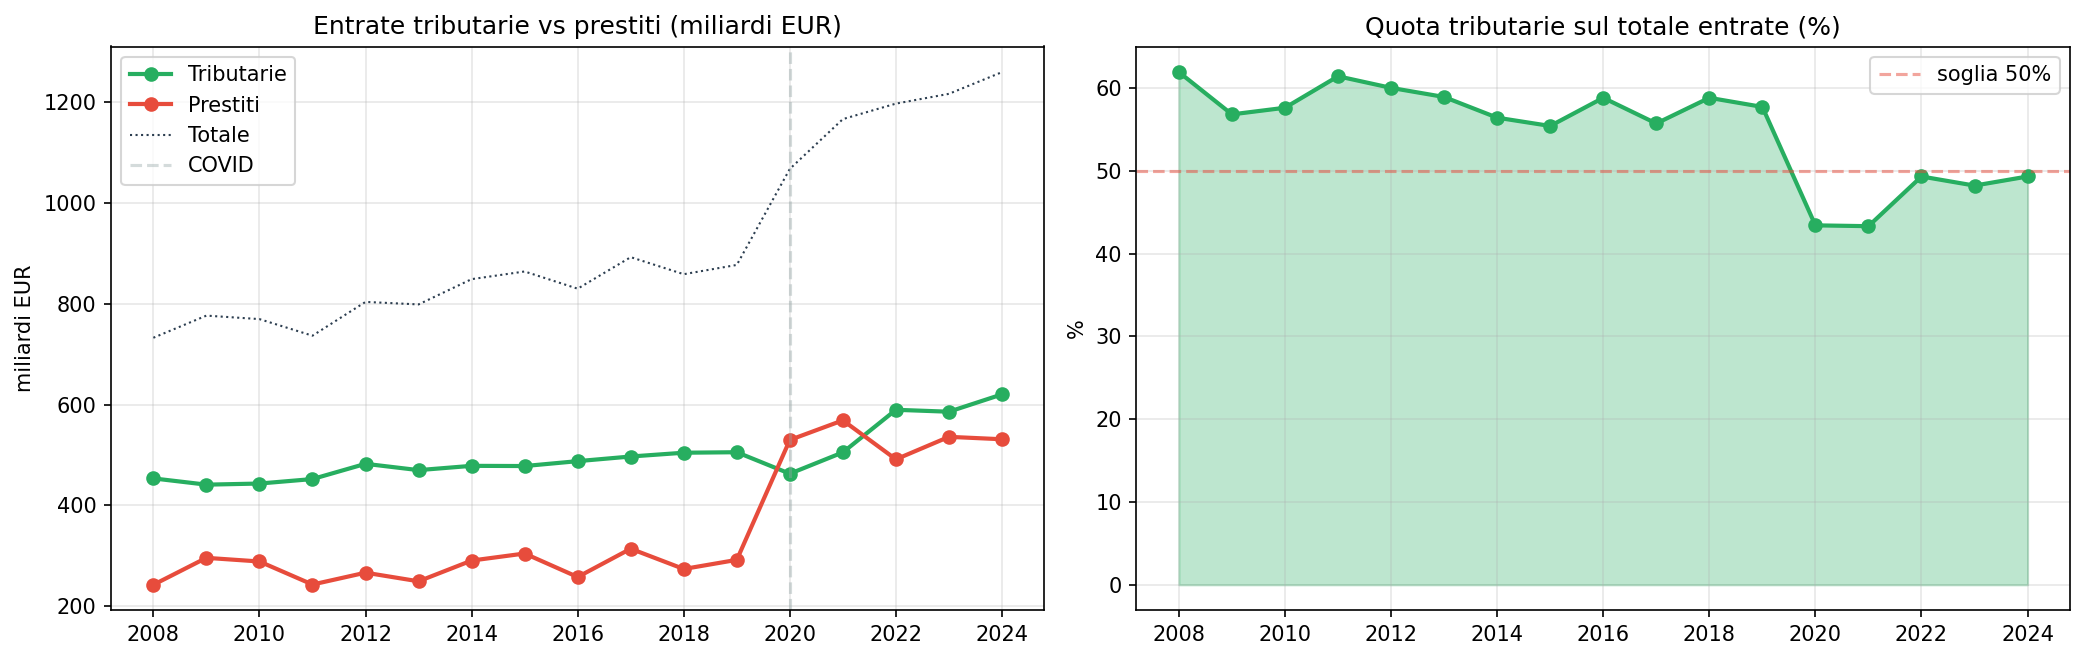

Salvato: figures/entrate_trend.png


In [3]:
# Grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(trend['anno'], trend['tributarie'], marker='o', linewidth=2, color='#27ae60', label='Tributarie')
ax1.plot(trend['anno'], trend['prestiti'], marker='o', linewidth=2, color='#e74c3c', label='Prestiti')
ax1.plot(trend['anno'], trend['totale'], marker='', linewidth=1, color='#2c3e50', linestyle=':', label='Totale')
ax1.axvline(x=2020, color='#95a5a6', linestyle='--', alpha=0.4, label='COVID')
ax1.set_title('Entrate tributarie vs prestiti (miliardi EUR)', fontsize=12)
ax1.set_ylabel('miliardi EUR')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.fill_between(trend['anno'], trend['pct_tributarie'], alpha=0.3, color='#27ae60')
ax2.plot(trend['anno'], trend['pct_tributarie'], marker='o', linewidth=2, color='#27ae60')
ax2.axhline(y=50, color='#e74c3c', linestyle='--', alpha=0.5, label='soglia 50%')
ax2.set_title('Quota tributarie sul totale entrate (%)', fontsize=12)
ax2.set_ylabel('%')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/entrate_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/entrate_trend.png')

In [4]:
# 2. Composizione 2024
comp2024 = con.execute(f"""
    SELECT titolo,
           CAST(SUM(previsioni_definitive_cp)/1e9 AS INTEGER) AS miliardi,
           ROUND(SUM(previsioni_definitive_cp) * 100.0 / SUM(SUM(previsioni_definitive_cp)) OVER(), 1) AS pct
    FROM read_parquet('{GCS}')
    WHERE esercizio_finanziario = 2024
    GROUP BY titolo
    ORDER BY miliardi DESC
""").fetchdf()

display(comp2024)

print(f"Tributarie: {comp2024.iloc[0]['miliardi']}B ({comp2024.iloc[0]['pct']}%)")
print(f"Prestiti: {comp2024.iloc[1]['miliardi']}B ({comp2024.iloc[1]['pct']}%)")

,titolo,miliardi,pct
0,TITOLO I - ENTRATE TRIBUTARIE,620,49.30
1,TITOLO IV - ACCENSIONE DI PRESTITI,531,42.20
2,TITOLO II - ENTRATE EXTRA-TRIBUTARIE,105,8.30
3,TITOLO III - ALIENAZIONE ED AMMORTAMENTO DI BE...,3,0.20


Tributarie: 620B (49.3%)
Prestiti: 531B (42.2%)


In [5]:
# 3. Focus pre-COVID vs post-COVID
confronto = con.execute("""
    SELECT
        ROUND(AVG(prestiti_pre), 1) AS media_prestiti_pre,
        ROUND(AVG(prestiti_post), 1) AS media_prestiti_post
    FROM (
        SELECT esercizio_finanziario AS anno,
               CASE WHEN esercizio_finanziario BETWEEN 2008 AND 2019
                    THEN CAST(SUM(CASE WHEN codice_titolo='4' THEN previsioni_definitive_cp ELSE 0 END) AS DOUBLE)/1e9 END AS prestiti_pre,
               CASE WHEN esercizio_finanziario >= 2020
                    THEN CAST(SUM(CASE WHEN codice_titolo='4' THEN previsioni_definitive_cp ELSE 0 END) AS DOUBLE)/1e9 END AS prestiti_post
        FROM read_parquet(?)
        GROUP BY esercizio_finanziario
    ) sub
""", [GCS]).fetchdf()

print(confronto)
print(f"Media prestiti pre-COVID (2008-2019): {confronto.iloc[0]['media_prestiti_pre']:.0f}B")
print(f"Media prestiti post-COVID (2020-2024): {confronto.iloc[0]['media_prestiti_post']:.0f}B")
print(f"Rapporto: x{confronto.iloc[0]['media_prestiti_post']/confronto.iloc[0]['media_prestiti_pre']:.1f}")


   media_prestiti_pre  media_prestiti_post
0              276.70               531.40
Media prestiti pre-COVID (2008-2019): 277B
Media prestiti post-COVID (2020-2024): 531B
Rapporto: x1.9


In [6]:
con.close()
print('Completato.')

Completato.
